In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib

In [2]:
# load the dataset
stock_data=pd.read_csv('stocks.csv')

In [ ]:
# rename the column
stock_data.rename(columns={'Ticker':'Company Name'},inplace=True)

# create pivot table between company_name and open price
company_and_open=pd.pivot_table(stock_data,values='Open',index='Company Name',aggfunc='mean')

# create pivot table between company_name and close price
company_and_close=pd.pivot_table(stock_data,values='Close',index='Company Name',aggfunc='mean')

# create pivot table between company_name and high price
company_and_high=pd.pivot_table(stock_data,values='High',index='Company Name',aggfunc='mean')

# create pivot table between company_name and low price
company_and_low=pd.pivot_table(stock_data,values='Low',index='Company Name',aggfunc='mean')

# create pivot table between open and close
open_and_close=pd.pivot_table(stock_data,values='Close',index='Open')

# create pivot table between high and low
high_and_low=pd.pivot_table(stock_data,values='Low',index='High')

In [40]:
def create_pieplot(data,start,end,title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a pie plot for a specified subset of data, with the colors of the slices 
    mapped based on the values of the data.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        title (str, optional): The title of the plot. Default is 'Data'.
        fig_width (int, optional): The width of the figure. Default is 20.
        fig_height (int, optional): The height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the pie slices. Default is 'Reds'.

    Returns:
        None: Displays the pie plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset[subset.columns[0]]
    
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = matplotlib.cm.get_cmap(colormap)  
    color = [cmap(norm(value)) for value in values]
    
    plt.pie(values, labels=subset.index, autopct='%1.1f%%', colors=color, startangle=0,
            pctdistance=0.75, labeldistance=1.1)
    plt.title(title, fontweight='bold')
    plt.axis('equal')
    plt.show()

In [52]:
def create_barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color,width=0.5, hue=subset.index)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

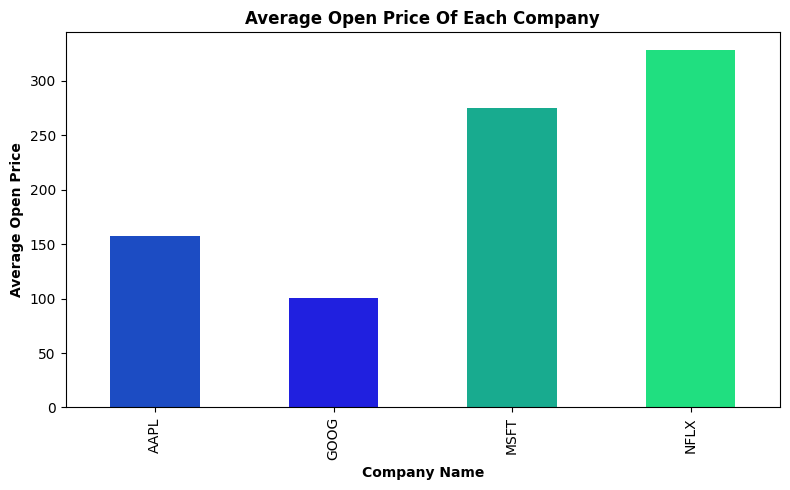

In [56]:
create_barplot(company_and_open,0,4,'Company Name','Average Open Price','Average Open Price Of Each Company',fig_width=8,fig_height=5,colormap='winter')

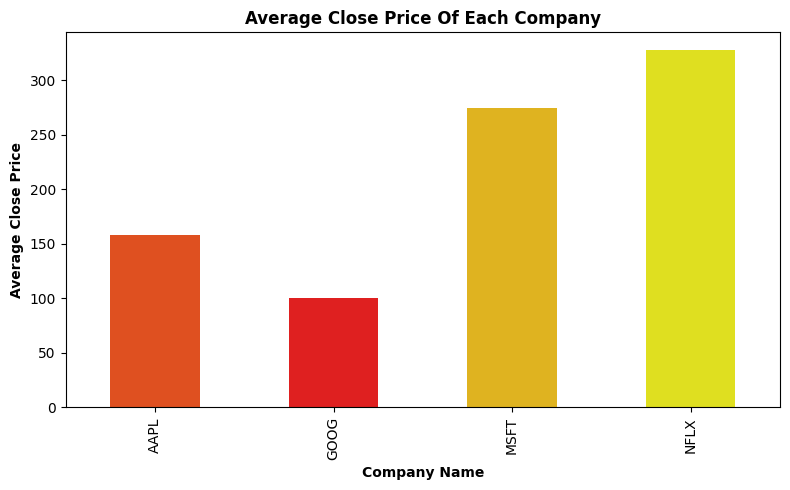

In [58]:
create_barplot(company_and_close,0,4,'Company Name','Average Close Price','Average Close Price Of Each Company',fig_width=8,fig_height=5,colormap='autumn') 

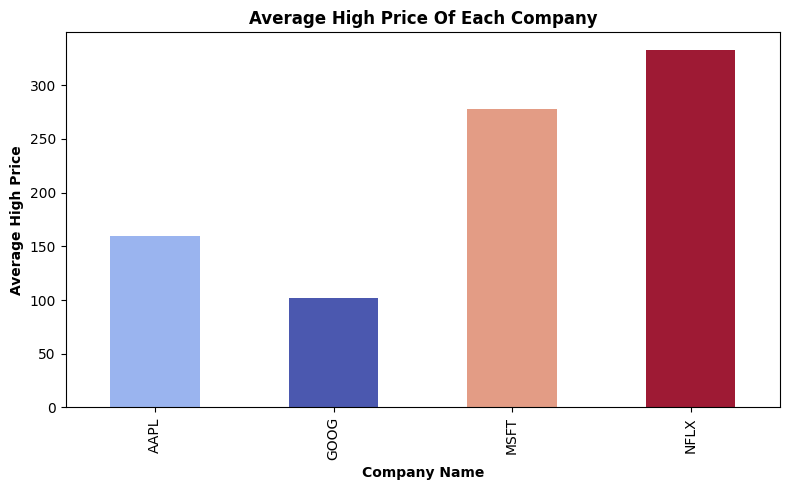

In [60]:
create_barplot(company_and_high,0,4,'Company Name','Average High Price','Average High Price Of Each Company',fig_width=8,fig_height=5,colormap='coolwarm')

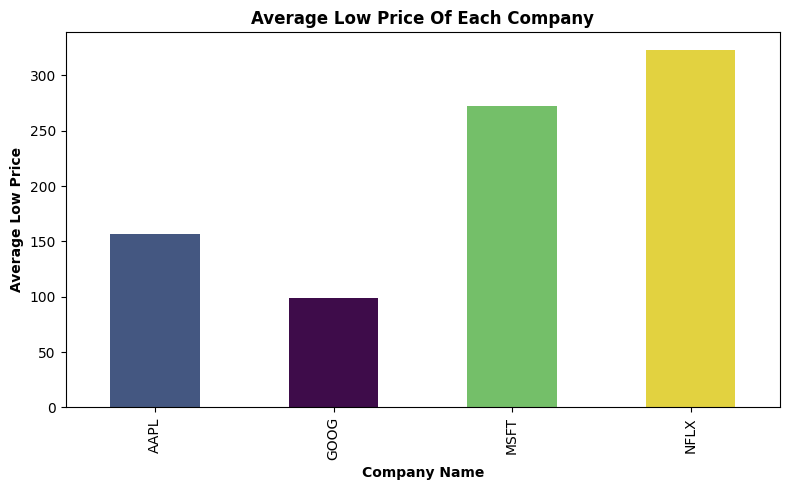

In [63]:
create_barplot(company_and_low,0,4,'Company Name','Average Low Price','Average Low Price Of Each Company',fig_width=8,fig_height=5,colormap='viridis')

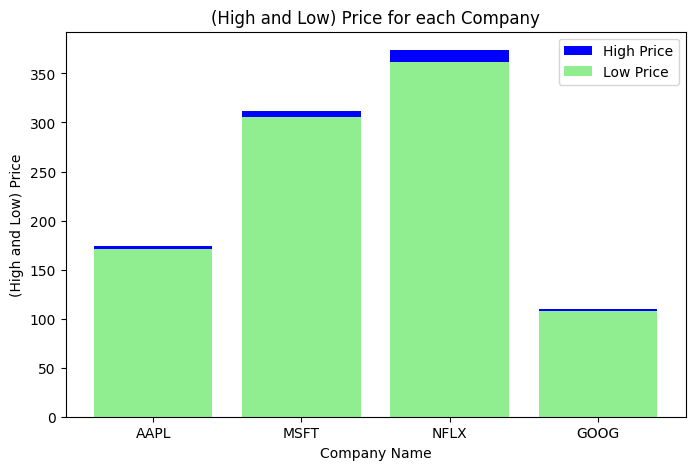

In [71]:
plt.figure(figsize= (8, 5))
plt.bar(stock_data['Company Name'],stock_data['High'], label= 'High Price',color='blue')
plt.bar(stock_data['Company Name'],stock_data['Low'], label= 'Low Price',color='lightgreen')
plt.xlabel('Company Name')
plt.ylabel('(High and Low) Price')
plt.title('(High and Low) Price for each Company')
plt.legend()
plt.show()

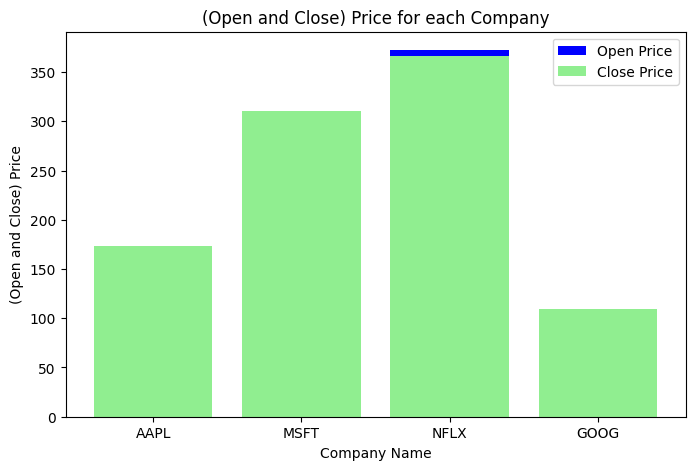

In [72]:
plt.figure(figsize= (8, 5))
plt.bar(stock_data['Company Name'],stock_data['Open'], label= 'Open Price',color='blue')
plt.bar(stock_data['Company Name'],stock_data['Close'], label= 'Close Price',color='lightgreen')
plt.xlabel('Company Name')
plt.ylabel('(Open and Close) Price')
plt.title('(Open and Close) Price for each Company')
plt.legend()
plt.show()

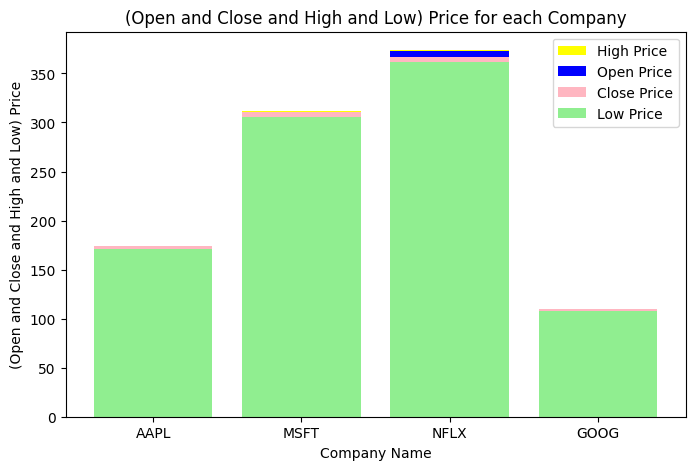

In [82]:
plt.figure(figsize= (8, 5))
plt.bar(stock_data['Company Name'],stock_data['High'], label= 'High Price',color='yellow')
plt.bar(stock_data['Company Name'],stock_data['Open'], label= 'Open Price',color='blue')
plt.bar(stock_data['Company Name'],stock_data['Close'], label= 'Close Price',color='lightpink')
plt.bar(stock_data['Company Name'],stock_data['Low'], label= 'Low Price',color='lightgreen')
plt.xlabel('Company Name')
plt.ylabel('(Open and Close and High and Low) Price')
plt.title('(Open and Close and High and Low) Price for each Company')
plt.legend()
plt.show()